In [ ]:
# Dependencies are managed in requirements.txt for reproducible setup.
# Install once in your environment before running this notebook.

In [ ]:
# pandas installed via requirements.txt

In [ ]:
# matplotlib installed via requirements.txt

In [ ]:
# scikit-learn installed via requirements.txt

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB 1.3 MB/s eta 0:00:09
   ---------------------------------------- 0.1/11.0 MB 1.3 MB/s eta 0:00:09
    --------------------------------------- 0.2/11.0 MB 1.4 MB/s eta 0:00:08
   - -------------------------------------- 0.3/11.0 MB 1.6 MB/s eta 0:00:07
   - -------------------------------------- 0.4/11.0 MB 1.6 MB/s eta 0:00:07
   -- ------------------------------------- 0.6/11.0 MB 2.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.0 MB 3.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.5/11.0 MB 4.0 MB/s eta 0:00:03
   ------- -------------------------------- 2.0/11.0 MB 5.0 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.0 MB 5.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.2/11.0 MB 6.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.8/11.0 MB 6.9 MB/s eta 0:00:02
   ---

In [ ]:
# scipy installed via requirements.txt

In [ ]:
# numpy and pandas upgrades are optional; keep environment pinned via requirements.txt

   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB 1.3 MB/s eta 0:00:10
   ---------------------------------------- 0.1/11.6 MB 1.3 MB/s eta 0:00:09
    --------------------------------------- 0.2/11.6 MB 1.6 MB/s eta 0:00:08
   - -------------------------------------- 0.3/11.6 MB 1.7 MB/s eta 0:00:07
   - -------------------------------------- 0.4/11.6 MB 1.9 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/11.6 MB 2.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.6 MB 3.2 MB/s eta 0:00:04
   ---- ----------------------------------- 1.4/11.6 MB 3.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.9/11.6 MB 4.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.5/11.6 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/11.6 MB 6.2 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.6 MB 6.7 MB/s eta 0:00:02
   ---

In [2]:
import pandas as pd

In [4]:
import numpy as np


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoLars, BayesianRidge, TweedieRegressor, SGDRegressor, \
    LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, LearningCurveDisplay, \
    ValidationCurveDisplay, validation_curve
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, SVC
import scipy.stats as stats
import pickle
import os

In [7]:
os.getcwd()

'C:\\Users\\User'

In [ ]:
# Keep notebook working directory unchanged for portability.

In [10]:
os.getcwd()

'C:\\Users\\User\\PycharmProjects\\Mlp'

In [ ]:
data_path = Path("../data/processed/features_round.csv")
if not data_path.exists():
    data_path = Path("features_round.csv")

db = pd.read_csv(data_path)  # Load csv as a DataFrame

In [12]:
labels = list(db.columns)[3:]  # Store the names of the features as a list
print(labels)

X_train, X_test, y_train, y_test = train_test_split(db[labels], db['y'], test_size=.25, random_state=42)

# Normalize Training-Set and store mean and SD for each of the variables
X_train_n, MU, SIGMA = (X_train - X_train.mean()) / X_train.std(), X_train.mean(), X_train.std()

# Normalize Test-Set according to the mean and SD computed for the Training-Set
X_test_n = (X_test - MU) / SIGMA

print('Initial Dataset: %.0f jumps, %.0f features' % (db.shape[0], len(labels)))
print('Train-Set: %.0f jumps' % (X_train_n.shape[0]))
print('Test-Set: %.0f jumps' % (X_test_n.shape[0]))



['h', 'A', 'b', 'C', 'D', 'e', 'F', 'G', 'H', 'i', 'J', 'k', 'l', 'M', 'n', 'O', 'p', 'q', 'r', 's', 'u', 'W', 'z', 'f3', 'f2', 'f1']
Initial Dataset: 44 jumps, 26 features
Train-Set: 33 jumps
Test-Set: 11 jumps


In [13]:

lasso_model = Lasso(alpha=.1)
lasso_model.fit(X_train_n, y_train)
coefs_lasso = list(np.round(lasso_model.coef_, 2))
lasso_betas = pd.DataFrame(np.round(lasso_model.coef_, 3), columns=["Beta"])
lasso_betas.index = labels
lasso_betas = lasso_betas[lasso_betas.Beta != 0]  # Remove deleted variables
labels_lasso = list(lasso_betas.index)  # Store the labels of the non-null features

# Store in memory the new Train and Test set with the Lasso-selected variables only
X_train_new = X_train_n[labels_lasso]
X_test_new = X_test_n[labels_lasso]

In [14]:
X = pd.concat([X_train_new, X_test_new])
y = pd.concat([y_train, y_test])

In [15]:
estimator = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42,
                                  min_samples_leaf=1, bootstrap=True)
estimator.fit(X_train_new, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

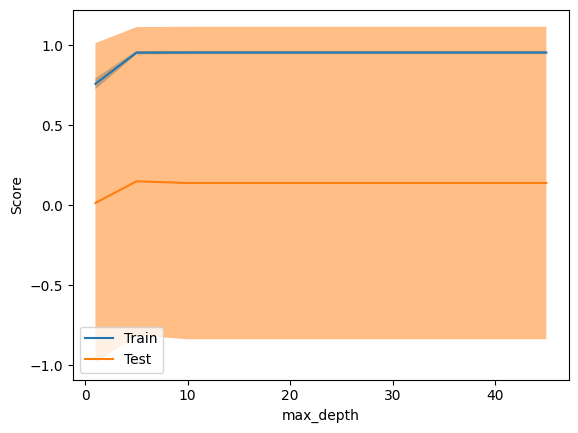

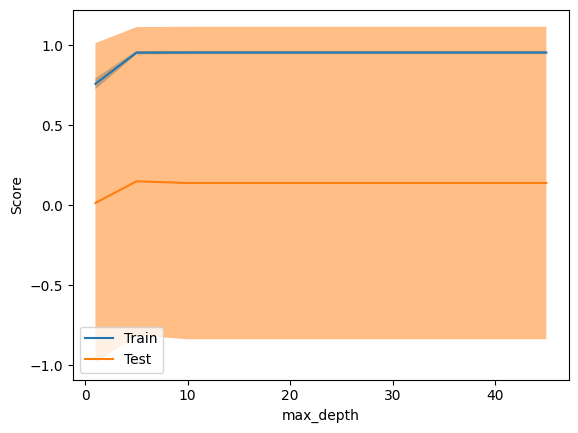

In [16]:
# 1)Validation Curve:
# plot the influence of a single hyperparameter on the training score and the validation score
# to find out whether the estimator is overfitting or underfitting for some hyperparameter values.
# ................................................................................................
disp = ValidationCurveDisplay.from_estimator(
   estimator, X_train_new, y_train, param_name="max_depth",
    param_range=[1, 5, 10, 15, 20, 25, 30, 35, 40, 45]
)
disp.plot()

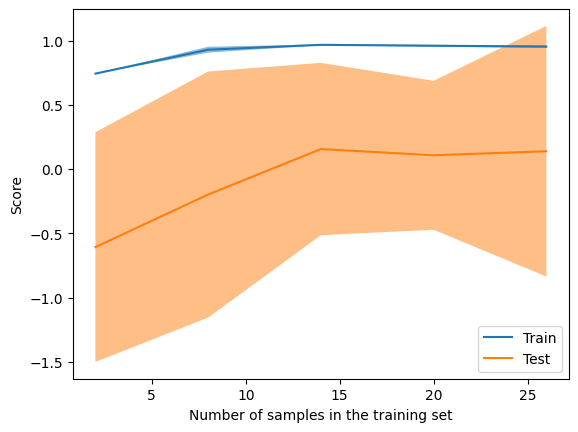

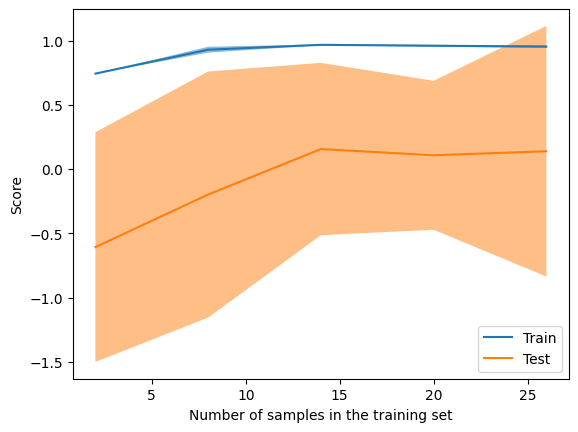

In [17]:
# 2)Learning Curve:A learning curve shows the validation and training score of an estimator for varying numbers of
# training samples. It is a tool to find out how much we benefit from adding more training data and whether the
# estimator suffers more from a variance error or a bias error
# ...............................................................................................
disp=LearningCurveDisplay.from_estimator(estimator,X_train_new,y_train)
disp.plot()

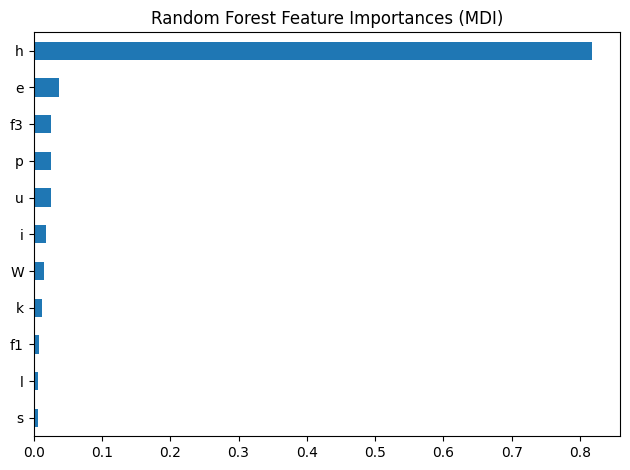

In [18]:
# 3)Permutation Feature Importance (PFI):Permutation feature importance is a model inspection technique
# that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset.
# ...........................................................................................................
feature_names = labels_lasso
mdi_importances = pd.Series(
     estimator.feature_importances_, index=feature_names
).sort_values(ascending=True)
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

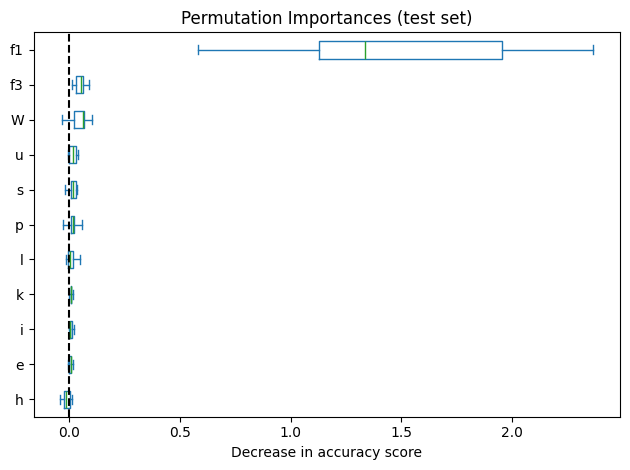

In [19]:
#4)PFI on the test samples
result = permutation_importance(
     estimator, X_test_new, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=labels_lasso
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

C:\Users\User\AppData\Local\Temp\ipykernel_19752\4054194425.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


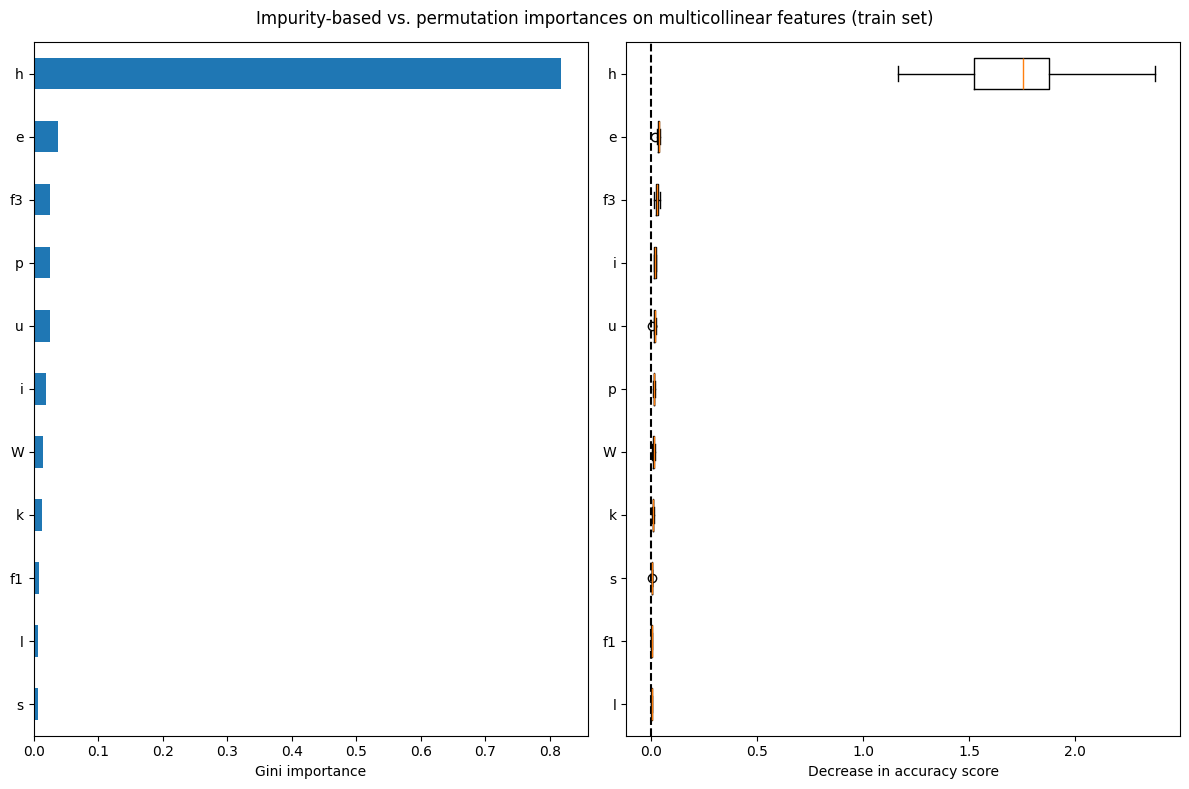

In [21]:
#5)Combination of the last two
clf=estimator
def plot_permutation_importance(clf, X, y, ax):
      result = permutation_importance(clf, X, y, n_repeats=10, random_state=42, n_jobs=2)
      perm_sorted_idx = result.importances_mean.argsort()

      ax.boxplot(
          result.importances[perm_sorted_idx].T,
         vert=False,
         labels=X.columns[perm_sorted_idx],
      )
      ax.axvline(x=0, color="k", linestyle="--")
      return ax
mdi_importances = pd.Series(clf.feature_importances_, index=X_train_new.columns)
tree_importance_sorted_idx = np.argsort(clf.feature_importances_)
tree_indices = np.arange(0, len(clf.feature_importances_)) + 0.5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
mdi_importances.sort_values().plot.barh(ax=ax1)
ax1.set_xlabel("Gini importance")
plot_permutation_importance(clf, X_train_new, y_train, ax2)
ax2.set_xlabel("Decrease in accuracy score")
fig.suptitle(
      "Impurity-based vs. permutation importances on multicollinear features (train set)"
)
_ = fig.tight_layout()

Baseline accuracy on test data with features removed: 0.48


C:\Users\User\AppData\Local\Temp\ipykernel_19752\2666924537.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


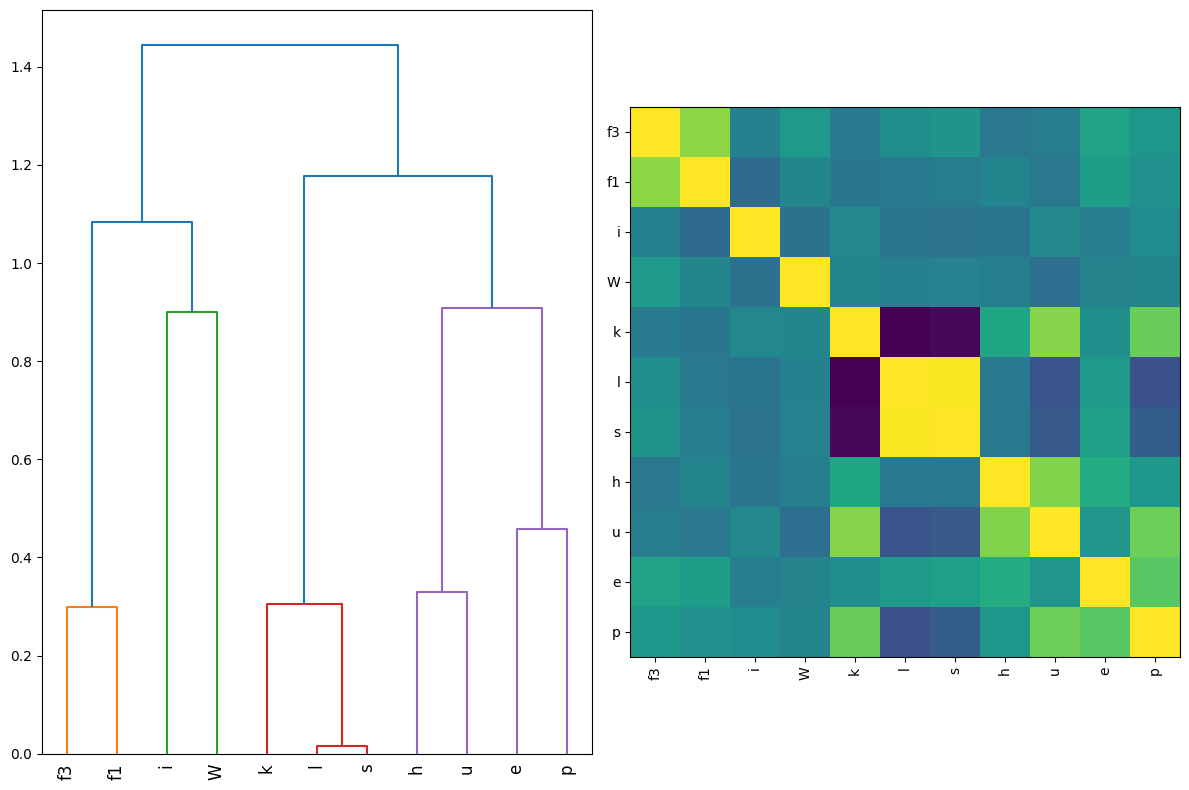

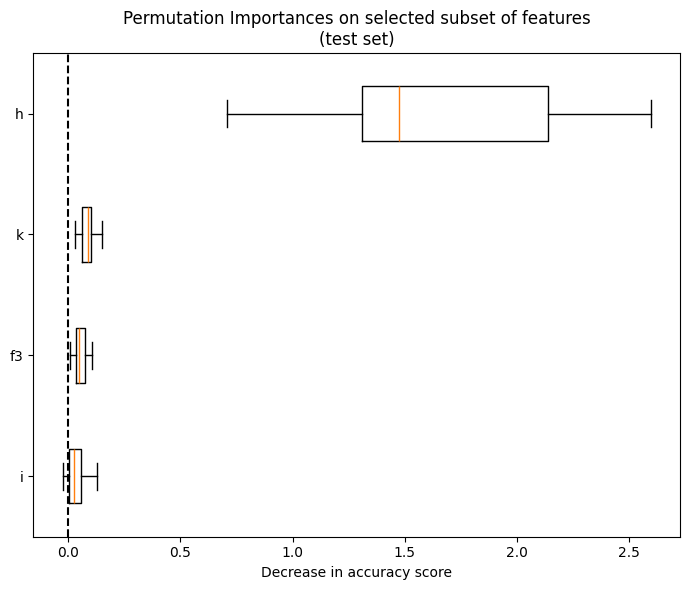

In [22]:
# 6)Permutation Importance with Multicollinear or Correlated Features
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = spearmanr(X).correlation

# # # Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)
# #
# # We convert the correlation matrix to a distance matrix before performing
# # hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax1, leaf_rotation=90
 )
dendro_idx = np.arange(0, len(dendro["ivl"]))

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
_ = fig.tight_layout()

from collections import defaultdict

def plot_permutation_importance(clf, X, y, ax):
      result = permutation_importance(clf, X, y, n_repeats=10, random_state=42, n_jobs=2)
      perm_sorted_idx = result.importances_mean.argsort()

      ax.boxplot(
          result.importances[perm_sorted_idx].T,
          vert=False,
          labels=X.columns[perm_sorted_idx],
      )
      ax.axvline(x=0, color="k", linestyle="--")
      return ax


cluster_ids = hierarchy.fcluster(dist_linkage, 1, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
      cluster_id_to_feature_ids[cluster_id].append(idx)
selected_features = [v[0] for v in cluster_id_to_feature_ids.values()]
selected_features_names = X.columns[selected_features]

X_train_sel = X_train_new[selected_features_names]
X_test_sel = X_test_new[selected_features_names]

clf_sel = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42,min_samples_leaf=1,bootstrap=True)
clf_sel.fit(X_train_sel, y_train)
print(
      "Baseline accuracy on test data with features removed:"
      f" {clf_sel.score(X_test_sel, y_test):.2}"
  )
fig, ax = plt.subplots(figsize=(7, 6))
plot_permutation_importance(clf_sel, X_test_sel, y_test, ax)
ax.set_title("Permutation Importances on selected subset of features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

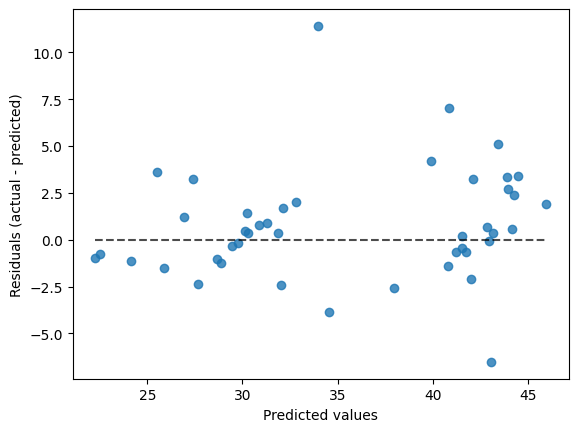

In [23]:
# 7)Visualization of the prediction error of a regression model.
disp = PredictionErrorDisplay.from_estimator(estimator, X, y)
plt.show()


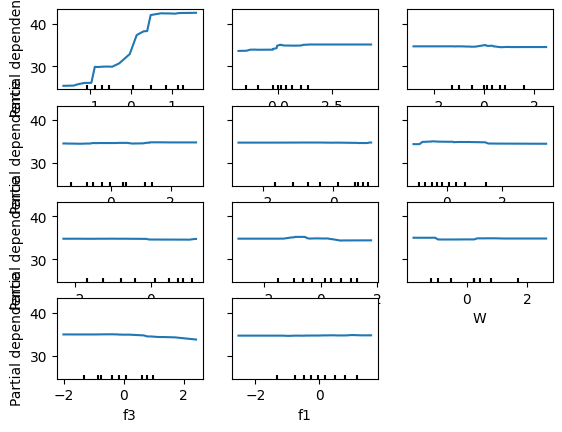

In [24]:
# 8)One Way PDP: tell us about the interaction between the target response and an input feature of interest
features=[]
for i in labels_lasso:
    features.append(i)
disp=PartialDependenceDisplay.from_estimator(estimator, X, features)
plt.show()

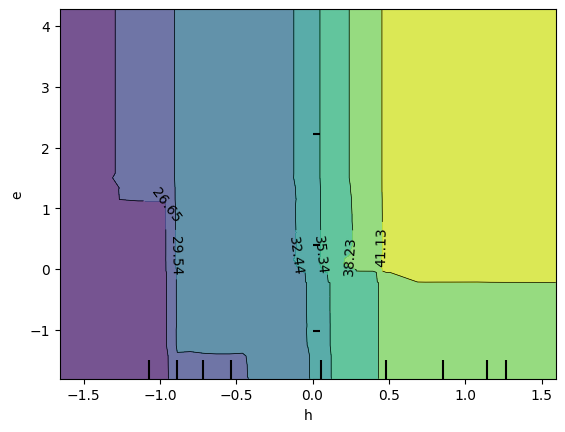

In [25]:
# 9)Two Way PDP: tell us about the interaction between the target response and an input feature of interest
features=[(labels_lasso.__getitem__(0),labels_lasso.__getitem__(1))]
disp=PartialDependenceDisplay.from_estimator(estimator, X, features)

plt.show()